### Métodos usados

In [5]:



def truncar(numero, decimales):
    """
    Trunca un número a un número específico de decimales.
    
    :param numero: El número a truncar
    :param decimales: Cuántos decimales mantener
    :return: Número truncado
    Ejemplo: original=0.335 → truncado=0.33 (2 decimales)
    """
    factor = 10 ** decimales
    return int(numero * factor) / factor


#función eplines cúbicos
def spline_cubico_natural(x, y, decimales = None):
    """
    Calcula los coeficientes del spline cúbico natural para puntos (x_i, y_i).
    
    :param x: lista de valores x (n+1 puntos)
    :param y: lista de valores y correspondientes
    :return: listas a, b, c, d para cada tramo j = 0, ..., n-1
    """
    n = len(x) - 1
    h = [x[i+1] - x[i] for i in range(n)]
    
    # Paso 2: calcular alpha
    alpha = [0] * (n+1)
    for i in range(1, n):
        alpha[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    
    # Paso 3: inicialización
    l = [1] + [0] * n
    mu = [0] * (n+1)
    z = [0] * (n+1)
    
    # Paso 4: resolver sistema tridiagonal
    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
    
    # Paso 5: condiciones naturales
    l[n] = 1
    z[n] = 0
    c = [0] * (n+1)
    
    # Paso 6: retro-substitución
    b = [0] * n
    d = [0] * n
    a = [y[j] for j in range(n)]
    
    for j in reversed(range(n)):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3 * h[j])
    
    #Paso 7: truncar decimales
    if decimales is not None:
        a = [truncar(val, decimales) for val in a]
        b = [truncar(val, decimales) for val in b]
        c = [truncar(val, decimales) for val in c[:n]]
        d = [truncar(val, decimales) for val in d]


    return a, b, c[:n], d


In [85]:
def newton(x0,f, df, tol=1e-6, num_iter=10):
    """
    Método de Newton-Raphson para encontrar una raíz de f(x).
    
    Parámetros:
        x0 (float): valor inicial (punto de partida)
        tol (float): tolerancia para el criterio de parada
        num_iter (int): número máximo de iteraciones
    
    Retorna:
        float: aproximación de la raíz
    """

    i=0
    while i<num_iter:
        x1 = x0 - f(x0)/df(x0)
        print ('iteracion: ', i, 'x = ', x0, 'f(x) = ', f(x0), "f'(x)=", df(x0), 'tolerancia', abs(x1 - x0))
        if abs(x1 - x0) < tol:
            print('La raiz es:', truncar(x1,4),'con interaciones', i)
            return truncar(x1,4)
        x0 = truncar(x1,4)
        i += 1
    print('El metodo falló depués de ', num_iter, 'iteraciones')
    return None


## datos filtrados y promediados 


In [ ]:
## cargar data set y filtar por uso de aire /no
import pandas as pd
datos = pd.read_csv('../Dataset/household_energy_consumption.csv')
#Asegurar que la columna de fecha esté en formato datetime
datos['Date'] = pd.to_datetime(datos['Date'])


#filtar datos por uso de aire acondicionado
datos_aire = datos[datos['Has_AC'] == 'Yes']
datos_aire.to_csv('../Dataset/datos_aire.csv', index=False)

#filtrar datos por no uso de aire acondicionado
datos_no_aire = datos[datos['Has_AC'] == 'No']
datos_no_aire.to_csv('../Dataset/datos_no_aire.csv', index=False)


#proemediar datos
promedio_aire = (
    datos_aire.groupby('Date').agg({
        'Energy_Consumption_kWh': 'mean',
        'Avg_Temperature_C': 'mean',
    }).reset_index()
)

promedio_no_aire = (
    datos_no_aire.groupby('Date').agg({
        'Energy_Consumption_kWh': 'mean',
        'Avg_Temperature_C': 'mean',
    }).reset_index()
)



In [ ]:
promedio_aire

,Date,Energy_Consumption_kWh,Avg_Temperature_C
0,2025-04-01,12.493361,17.529531
1,2025-04-02,12.519572,17.486611
2,2025-04-03,12.497483,17.492952
3,2025-04-04,12.524717,17.472687
4,2025-04-05,12.532111,17.527218
5,2025-04-06,12.473836,17.472907
6,2025-04-07,12.518754,17.540387


In [88]:
promedio_no_aire

,Date,Energy_Consumption_kWh,Avg_Temperature_C
0,2025-04-01,8.704984,17.509829
1,2025-04-02,8.676004,17.543547
2,2025-04-03,8.678680,17.509752
3,2025-04-04,8.679726,17.503692
4,2025-04-05,8.655591,17.543670
5,2025-04-06,8.681634,17.492047
6,2025-04-07,8.674250,17.455884
7,2025-04-08,7.200000,18.200000


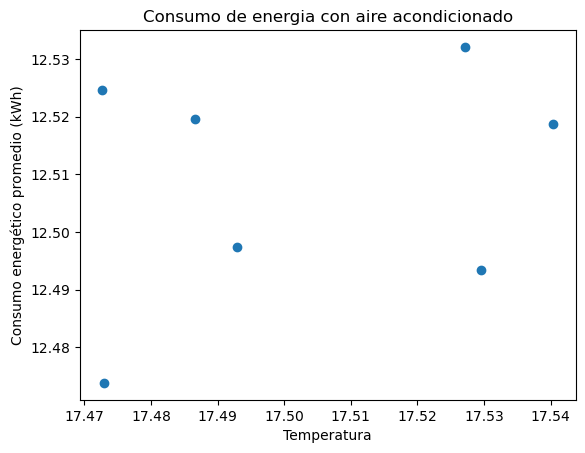

In [89]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(promedio_aire['Avg_Temperature_C'], promedio_aire['Energy_Consumption_kWh'])
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético promedio (kWh)")
plt.title("Consumo de energia con aire acondicionado")
plt.show()

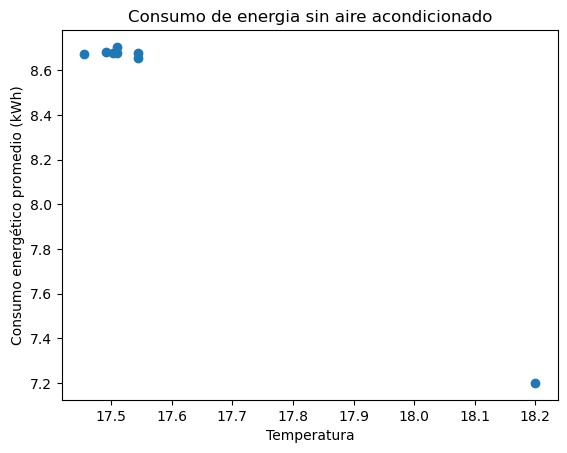

In [90]:
plt.figure()
plt.scatter(promedio_no_aire['Avg_Temperature_C'], promedio_no_aire['Energy_Consumption_kWh'])
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético promedio (kWh)")
plt.title("Consumo de energia sin aire acondicionado")
plt.show()

In [91]:
puntos_aire_x = promedio_aire['Avg_Temperature_C'].tolist()
puntos_aire_y = promedio_aire['Energy_Consumption_kWh'].tolist()
puntos_no_aire_x = promedio_no_aire['Avg_Temperature_C'].tolist()
puntos_no_aire_y = promedio_no_aire['Energy_Consumption_kWh'].tolist() 
# Unir x e y
puntos_aire = list(zip(puntos_aire_x, puntos_aire_y))
puntos_no_aire = list(zip(puntos_no_aire_x, puntos_no_aire_y))

# Ordenar por x
puntos_aire.sort(key=lambda p: p[0])
puntos_no_aire.sort(key=lambda p: p[0])

# Separar nuevamente
puntos_aire_x = [p[0] for p in puntos_aire]
puntos_aire_y = [p[1] for p in puntos_aire]


puntos_no_aire_x = [p[0] for p in puntos_no_aire]
puntos_no_aire_y = [p[1] for p in puntos_no_aire]

In [92]:
a1, b1, c1, d1 = spline_cubico_natural(puntos_aire_x, puntos_aire_y, decimales=4)
a2, b2, c2, d2 = spline_cubico_natural(puntos_no_aire_x, puntos_no_aire_y, decimales=4)

# Mostrar resultados
for j in range(len(a1)):
    print(f"Tramo {j}: S(x) = {a1[j]} + {b1[j]}*(x - {truncar(puntos_aire_x[j], 4)}) + {c1[j]}*(x - {truncar(puntos_aire_x[j], 4)})**2 + {d1[j]}*(x - {truncar(puntos_aire_x[j], 4)})**3")

for j in range(len(a2)):
    print(f"Tramo {j}: S(x) = {a2[j]} + {b2[j]}*(x - {truncar(puntos_no_aire_x[j], 4)}) + {c2[j]}*(x - {truncar(puntos_no_aire_x[j], 4)})**2 + {d2[j]}*(x - {truncar(puntos_no_aire_x[j], 4)})**3") 


Tramo 0: S(x) = 12.5247 + -233.2624*(x - 17.4726) + 0.0*(x - 17.4726)**2 + 46632026.6284*(x - 17.4726)**3
Tramo 1: S(x) = 12.4738 + -226.4751*(x - 17.4729) + 30814.1145*(x - 17.4729)**2 + -1024830.5837*(x - 17.4729)**3
Tramo 2: S(x) = 12.5195 + 40.699*(x - 17.4866) + -11317.4511*(x - 17.4866)**2 + 685919.1279*(x - 17.4866)**3
Tramo 3: S(x) = 12.4974 + -20.0918*(x - 17.4929) + 1729.6889*(x - 17.4929)**2 + -32505.5926*(x - 17.4929)**3
Tramo 4: S(x) = 12.5321 + -16.0556*(x - 17.5272) + -1611.9023*(x - 17.5272)**2 + 566190.2383*(x - 17.5272)**3
Tramo 5: S(x) = 12.4933 + -14.426*(x - 17.5295) + 2316.51*(x - 17.5295)**2 + -71129.1697*(x - 17.5295)**3
Tramo 0: S(x) = 8.6742 + -23.6811*(x - 17.4558) + 0.0*(x - 17.4558)**2 + 18263.5557*(x - 17.4558)**3
Tramo 1: S(x) = 8.6816 + 47.9747*(x - 17.492) + 1981.4314*(x - 17.492)**2 + -525189.2675*(x - 17.492)**3
Tramo 2: S(x) = 8.6797 + -119.5133*(x - 17.5036) + -16365.051*(x - 17.5036)**2 + 5949285.8976*(x - 17.5036)**3
Tramo 3: S(x) = 8.6786 + 337.6

In [93]:
def evaluar_spline(x_eval, x, a, b, c, d):
    """
    Evalúa el spline cúbico en los puntos x_eval
    """
    y_eval = []

    for xv in x_eval:
        # buscar el tramo correcto
        for j in range(len(a)):
            if x[j] <= xv <= x[j+1]:
                dx = xv - x[j]
                yv = a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
                y_eval.append(yv)
                break

    return y_eval


In [94]:
import numpy as np

x_spline_aire = []
for j in range(len(a1)):
    x_tramo = np.linspace(puntos_aire_x[j], puntos_aire_x[j+1], 50)
    x_spline_aire.extend(x_tramo)

y_spline_aire = evaluar_spline(x_spline_aire, puntos_aire_x, a1, b1, c1, d1)

x_spline_no_aire = []
for j in range(len(a2)):
    x_tramo = np.linspace(puntos_no_aire_x[j], puntos_no_aire_x[j+1], 50)
    x_spline_no_aire.extend(x_tramo)
y_spline_no_aire = evaluar_spline(x_spline_no_aire, puntos_no_aire_x, a2, b2, c2, d2)



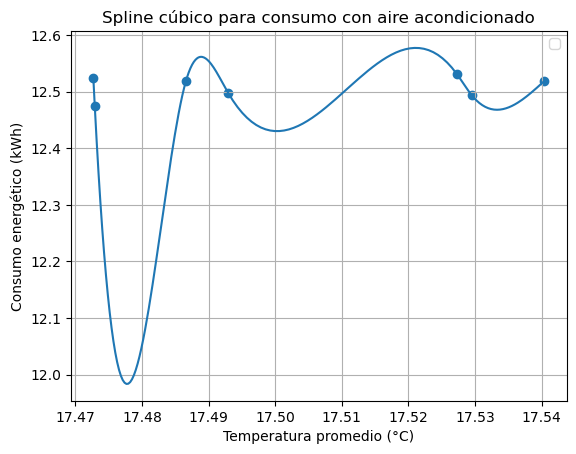

In [95]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(x_spline_aire, y_spline_aire, label="Spline cúbico")
plt.scatter(puntos_aire_x, puntos_aire_y, label="Datos originales")
plt.xlabel("Temperatura promedio (°C)")
plt.ylabel("Consumo energético (kWh)")
plt.title("Spline cúbico para consumo con aire acondicionado")
plt.legend("")
plt.grid(True)
plt.show()


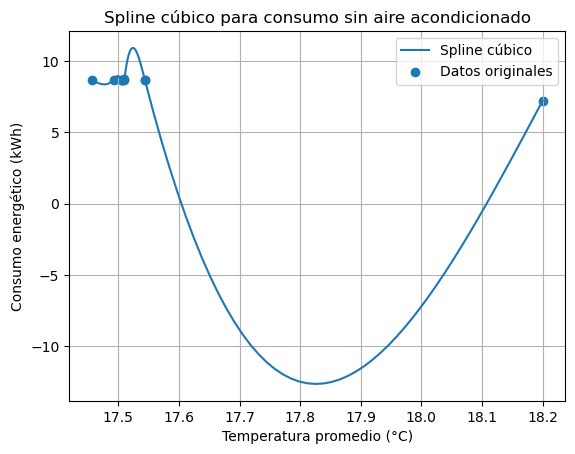

In [96]:
plt.figure()
plt.plot(x_spline_no_aire, y_spline_no_aire, label="Spline cúbico")
plt.scatter(puntos_no_aire_x, puntos_no_aire_y, label="Datos originales")
plt.xlabel("Temperatura promedio (°C)")
plt.ylabel("Consumo energético (kWh)")
plt.title("Spline cúbico para consumo sin aire acondicionado")
plt.legend()
plt.grid(True)
plt.show()

### etapa 3 identififcar picos y valles

In [97]:
def derivada_spline(xv, x, a, b, c, d):
    for j in range(len(a)):
        if x[j] <= xv <= x[j+1]:
            dx = xv - x[j]
            return b[j] + 2*c[j]*dx + 3*d[j]*dx**2
    return None


def segunda_derivada_spline(xv, x, a, b, c, d):
    for j in range(len(a)):
        if x[j] <= xv <= x[j+1]:
            dx = xv - x[j]
            return 2*c[j] + 6*d[j]*dx
    return None


In [98]:
#definir f(x) y su derivada f'(x)
def f1(xv):
    return derivada_spline(xv, puntos_aire_x, a1, b1, c1, d1)

def df1(xv):
    return segunda_derivada_spline(xv, puntos_aire_x, a1, b1, c1, d1)

def f2(xv):
    return derivada_spline(xv, puntos_no_aire_x, a2, b2, c2, d2)

def df2(xv):
    return segunda_derivada_spline(xv, puntos_no_aire_x, a2, b2, c2, d2)

In [99]:
extremos = []

# Envolver f1/df1 para devolver valores válidos dentro del dominio del spline
def f1_safe(xv):
    val = f1(xv)
    return val if val is not None else 0.0  # evita TypeError si se sale del dominio

def df1_safe(xv):
    val = df1(xv)
    # si la segunda derivada no está definida, evitar división por cero
    return val if val not in (None, 0.0) else 1e-6

for j in range(len(a1)):
    # usar el punto medio del tramo j
    x_left = puntos_aire_x[j]
    x_right = puntos_aire_x[j+1]
    x0 = (x_left + x_right) / 2.0
    print(f" Tramo {j}")
    raiz = newton(x0, f1_safe, df1_safe)

    # verificar que la raíz esté en el tramo actual
    if raiz is not None and x_left <= raiz <= x_right:
        extremos.append(raiz)


 Tramo 0
iteracion:  0 x =  17.472797356828195 f(x) =  -231.56558752678703 f'(x)= 30814.11451285309 tolerancia 0.0075149194188348645
iteracion:  1 x =  17.4803 f(x) =  61.0936883403688 f'(x)= 16171.800739908285 tolerancia 0.0037777913123555606
iteracion:  2 x =  17.4765 f(x) =  -44.75481535709748 f'(x)= 39537.93804825752 tolerancia 0.0011319461147039078
iteracion:  3 x =  17.4776 f(x) =  -4.983218522929249 f'(x)= 32774.056195853285 tolerancia 0.00015204765907483875
iteracion:  4 x =  17.4777 f(x) =  -1.7365578208624015 f'(x)= 32159.15784563472 tolerancia 5.399885871426591e-05
iteracion:  5 x =  17.4777 f(x) =  -1.7365578208624015 f'(x)= 32159.15784563472 tolerancia 5.399885871426591e-05
iteracion:  6 x =  17.4777 f(x) =  -1.7365578208624015 f'(x)= 32159.15784563472 tolerancia 5.399885871426591e-05
iteracion:  7 x =  17.4777 f(x) =  -1.7365578208624015 f'(x)= 32159.15784563472 tolerancia 5.399885871426591e-05
iteracion:  8 x =  17.4777 f(x) =  -1.7365578208624015 f'(x)= 32159.1578456347

In [17]:
#importer, limpiar y ordenar datasets 
import pandas as pd


#importear dataset 
ds = pd.read_csv('../Dataset/household_energy_consumption.csv')
ds =  ds[['Avg_Temperature_C', 'Energy_Consumption_kWh', 'Has_AC']]

#filtrar datos por uso de aire acondicionado y sin uso de aire acondicionado
ds_aire = ds[ds['Has_AC'] == 'Yes']
ds_no_aire = ds[ds['Has_AC'] == 'No']

#=Eliminar columna Has_AC y filas 
ds_aire = ds_aire[['Avg_Temperature_C', 'Energy_Consumption_kWh' ]]
ds_no_aire = ds_no_aire[['Avg_Temperature_C', 'Energy_Consumption_kWh' ]]

#limpiar datos nulos
ds_aire=ds_aire.dropna()
ds_no_aire=ds_no_aire.dropna()

#Eliminar datos repetidos
ds_no_aire = ds_no_aire.groupby(['Avg_Temperature_C']).mean().reset_index()
ds_aire = ds_aire.groupby(['Avg_Temperature_C']).mean().reset_index()

#ordenar datos por temperatura
ds_aire = ds_aire.sort_values(by='Avg_Temperature_C')
ds_no_aire = ds_no_aire.sort_values(by='Avg_Temperature_C')

#guardar datos limpios
ds_aire.to_csv('../Dataset/datos_aire.csv', index=False)
ds_no_aire.to_csv('../Dataset/datos_no_aire.csv', index=False)


#mostrar primeras filas de los datasets limpios
print(ds_aire.head())
print(ds_no_aire.head())





   Avg_Temperature_C  Energy_Consumption_kWh
0               10.0               12.047619
1               10.1               13.800000
2               10.2               10.181818
3               10.3               10.712500
4               10.4               14.190000
   Avg_Temperature_C  Energy_Consumption_kWh
0               10.0                8.074648
1               10.1                8.185714
2               10.2                8.293750
3               10.3                7.008333
4               10.4                9.758333


In [44]:
x_aire =  ds_aire['Avg_Temperature_C'].tolist()
y_aire =  ds_aire['Energy_Consumption_kWh'].tolist()


x_no_aire =  ds_no_aire['Avg_Temperature_C'].tolist()
y_no_aire =  ds_no_aire['Energy_Consumption_kWh'].tolist()



In [41]:
a, b, c, d, = spline_cubico_natural(x_aire, y_aire, decimales = 4)
a1, b1, c1, d1 = spline_cubico_natural(x_no_aire, y_no_aire, decimales = 4)


def evaluar_spline(x_eval, x, a, b, c, d):
      
    for j in range(len(a)):
            if x[j] <= x_eval <= x[j+1]:
                dx = x_eval - x[j]
                return a[j] + b[j]*dx + c[j]*dx**2 + d[j]*dx**3
    return None

#y_no_aire = [evaluar_spline(xv, x_no_aire, a1, b1, c1, d1) for xv in x_no_aire]
#y_aire = [evaluar_spline(xv, x_aire, a, b, c, d) for xv in x_aire]

Text(0.5, 1.0, 'Consumo de energia con aire acondicionado')

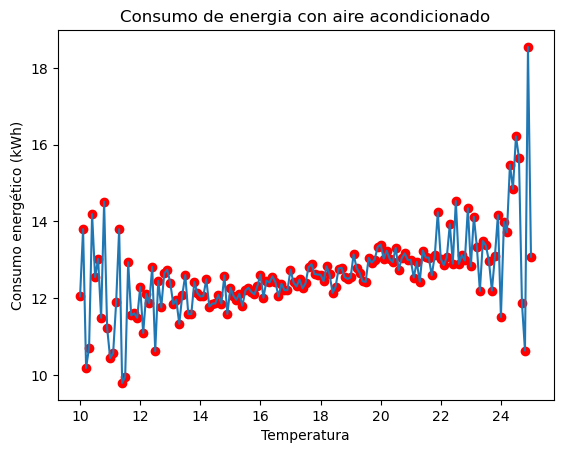

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(x_aire, y_aire, color='red')
plt.plot(x_aire, y_aire)
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético (kWh)")
plt.title("Consumo de energia con aire acondicionado")

Text(0.5, 1.0, 'Consumo de energia sin aire acondicionado')

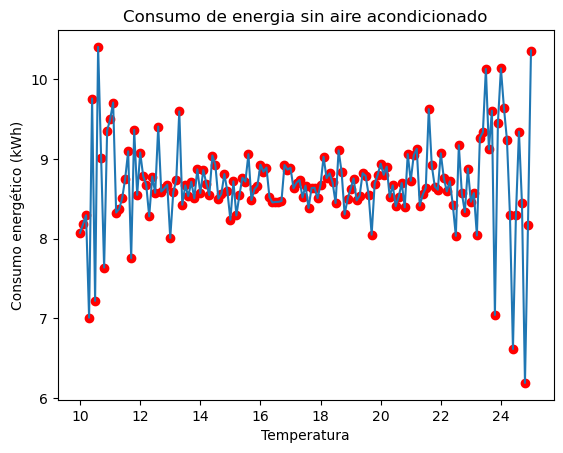

In [43]:
plt.figure()
plt.scatter(x_no_aire, y_no_aire, color='red')

plt.plot(x_no_aire, y_no_aire)
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético (kWh)")
plt.title("Consumo de energia sin aire acondicionado")

Text(0.5, 1.0, 'Consumo de energia con aire acondicionado')

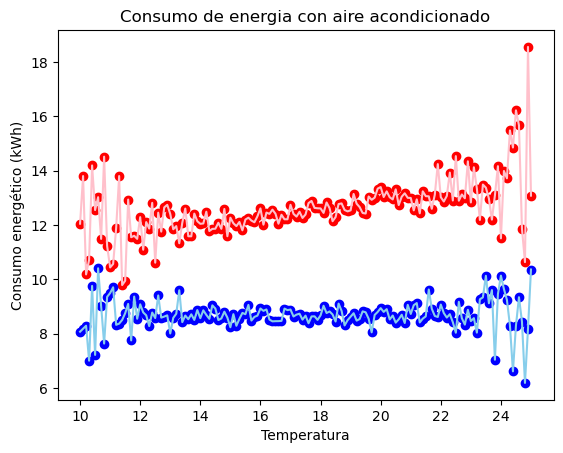

In [39]:
plt.figure()
plt.scatter(x_aire, y_aire, color='red')
plt.scatter(x_no_aire, y_no_aire, color='blue')
plt.plot(x_aire, y_aire, color='pink')
plt.plot(x_no_aire, y_no_aire, color='skyblue')
plt.xlabel("Temperatura")
plt.ylabel("Consumo energético (kWh)")
plt.title("Consumo de energia con aire acondicionado")